<a href="https://colab.research.google.com/github/Faizzyyy13/WNN-Human-Activity-Recognition/blob/main/WNN_WISDOM_V2_RESULTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('time_series_data_human_activities.csv')
df.head()

,user,activity,timestamp,x-axis,y-axis,z-axis
0,1,Walking,4991922345000,0.69,10.80,-2.03
1,1,Walking,4991972333000,6.85,7.44,-0.50
2,1,Walking,4992022351000,0.93,5.63,-0.50
3,1,Walking,4992072339000,-2.11,5.01,-0.69
4,1,Walking,4992122358000,-4.59,4.29,-1.95


In [ ]:
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
df.describe()

print("\nMissing Values:")
print(df.isnull().sum())

# Convert 'timestamp' to datetime, coercing out-of-bounds values to NaT
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')
print("\n'timestamp' column after conversion:")
df.info()

# Check for NaT values introduced by coercion
print("\nNumber of NaT values in 'timestamp' after conversion:")
print(df['timestamp'].isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1073623 entries, 0 to 1073622
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user       1073623 non-null  int64  
 1   activity   1073623 non-null  object 
 2   timestamp  1073623 non-null  int64  
 3   x-axis     1073623 non-null  float64
 4   y-axis     1073623 non-null  float64
 5   z-axis     1073623 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 49.1+ MB

Descriptive Statistics:

Missing Values:
user         0
activity     0
timestamp    0
x-axis       0
y-axis       0
z-axis       0
dtype: int64

'timestamp' column after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1073623 entries, 0 to 1073622
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   user       1073623 non-null  int64         
 1   activity   1073623 non-nul

In [ ]:
print(f"Initial number of rows: {len(df)}")

# Drop rows where 'timestamp' is NaT
df.dropna(subset=['timestamp'], inplace=True)
print(f"Number of rows after dropping NaT in timestamp: {len(df)}")

# Verify no NaT values remain
print("\nMissing values after dropping NaT:")
print(df.isnull().sum())

# Sort the DataFrame by 'timestamp'
df.sort_values(by='timestamp', inplace=True)
print("\nDataFrame sorted by 'timestamp'. First 5 rows:")
print(df.head())
print("\nDataFrame Info after cleaning and sorting:")
df.info()

Initial number of rows: 1073623
Number of rows after dropping NaT in timestamp: 526155

Missing values after dropping NaT:
user         0
activity     0
timestamp    0
x-axis       0
y-axis       0
z-axis       0
dtype: int64

DataFrame sorted by 'timestamp'. First 5 rows:
         user  activity           timestamp  x-axis  y-axis  z-axis
1019121    35  Standing 1972-04-30 03:25:42    2.03    9.47    2.91
1019122    35  Standing 1972-04-30 17:18:50    2.15    9.30    2.83
1019123    35  Standing 1972-05-01 07:12:28    2.22    9.38    2.83
1019124    35  Standing 1972-05-01 21:05:36    2.37    9.34    3.02
1019125    35  Standing 1972-05-02 10:58:44    2.30    9.28    2.83

DataFrame Info after cleaning and sorting:
<class 'pandas.core.frame.DataFrame'>
Index: 526155 entries, 1019121 to 847169
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   user       526155 non-null  int64         
 1   activity   526

In [ ]:
import numpy as np

# 1. Define window_size and stride parameters
window_size = 100
stride = 50

# 2. Select the feature columns
feature_cols = ['x-axis', 'y-axis', 'z-axis']

# 3. Create empty lists to store the generated windows and labels
windowed_features = []
windowed_labels = []

# 4. Iterate through the preprocessed DataFrame
# The grouping by user and activity is crucial to ensure windows don't cross boundaries
for user_id in df['user'].unique():
    user_df = df[df['user'] == user_id].copy()
    for activity_label in user_df['activity'].unique():
        activity_df = user_df[user_df['activity'] == activity_label].copy()

        # Reset index for proper slicing
        activity_df = activity_df.reset_index(drop=True)

        for i in range(0, len(activity_df) - window_size + 1, stride):
            # 5. Extract a segment of the feature columns of window_size length
            # 6. Ensure that each extracted window does not cross boundaries of 'user' or 'activity'
            # This is handled by iterating within groups of user and activity
            window = activity_df.loc[i : i + window_size - 1, feature_cols].values

            # 7. For each valid window, extract the features and the dominant 'activity' label
            # Since we iterate within a single activity block, the label is consistent.
            label = activity_df.loc[i, 'activity'] # Use the activity label at the start of the window

            # 8. Append the extracted feature window and its corresponding label to the respective lists
            windowed_features.append(window)
            windowed_labels.append(label)

# 9. Convert the lists of windows and labels into NumPy arrays
X = np.array(windowed_features)
y = np.array(windowed_labels)

print(f"Original DataFrame shape: {df.shape}")
print(f"Number of generated windows: {len(windowed_features)}")
print(f"Shape of windowed features (X): {X.shape}")
print(f"Shape of windowed labels (y): {y.shape}")

# Summarize the preprocessing and windowing steps
print("\n--- Preprocessing and Windowing Summary ---")
print("Preprocessing Steps:")
print("- Loaded 'time_series_data_human_activities.csv' into a pandas DataFrame.")
print("- Converted 'timestamp' column to datetime objects, coercing out-of-bounds values to NaT.")
print("- Dropped rows with NaT values in the 'timestamp' column.")
print("- Sorted the DataFrame by 'timestamp'.")
print("\nWindowing Strategy:")
print(f"- Window size: {window_size} (number of time steps per window)")
print(f"- Stride: {stride} (number of time steps to advance for the next window)")
print("- Feature columns used: {feature_cols}")
print("- Windows were created by iterating through unique 'user' and 'activity' groups to ensure sequence integrity.")
print("- Each window contains {window_size} time steps for x-axis, y-axis, and z-axis acceleration data.")
print("- The label for each window corresponds to the 'activity' within that window.")

print("\nResulting Windowed Dataset:")
print(f"- Total number of windows generated: {X.shape[0]}")
print(f"- Each feature window has a shape of (time_steps, features): {X.shape[1:]}")
print(f"- The labels array has a shape of (number_of_windows,): {y.shape}")
print(f"- Example of a feature window (first window):\n{X[0]}")
print(f"- Example of a corresponding label (first label): {y[0]}")

Original DataFrame shape: (526155, 6)
Number of generated windows: 10385
Shape of windowed features (X): (10385, 100, 3)
Shape of windowed labels (y): (10385,)

--- Preprocessing and Windowing Summary ---
Preprocessing Steps:
- Loaded 'time_series_data_human_activities.csv' into a pandas DataFrame.
- Converted 'timestamp' column to datetime objects, coercing out-of-bounds values to NaT.
- Dropped rows with NaT values in the 'timestamp' column.
- Sorted the DataFrame by 'timestamp'.

Windowing Strategy:
- Window size: 100 (number of time steps per window)
- Stride: 50 (number of time steps to advance for the next window)
- Feature columns used: {feature_cols}
- Windows were created by iterating through unique 'user' and 'activity' groups to ensure sequence integrity.
- Each window contains {window_size} time steps for x-axis, y-axis, and z-axis acceleration data.
- The label for each window corresponds to the 'activity' within that window.

Resulting Windowed Dataset:
- Total number of 

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (Layer, Dense, Input, Dropout,
                                     Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D,
                                     MaxPooling1D, BatchNormalization, Concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras import initializers, constraints
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, f1_score
import itertools

# ==============================================================================
# 1. CUSTOM LAYER: Auto-Grouped Wavelet Layer (Power Set)
# ==============================================================================
def morlet_wavelet(x):
    """Morlet wavelet activation function."""
    x = tf.clip_by_value(x, -10.0, 10.0)
    return tf.exp(-0.5 * tf.square(x)) * tf.cos(5.0 * x)

class AutoGroupedWaveletLayer(Layer):
    """
    Learns a separate weighted sum and Wavelet activation for EVERY possible
    unique combination of inputs (Power Set).
    """
    def __init__(self, **kwargs):
        super(AutoGroupedWaveletLayer, self).__init__(**kwargs)
        self.supports_masking = False

    def build(self, input_shape):
        input_dim = input_shape[-1]

        # --- GENERATE POWER SET COMBINATIONS ---
        # For 9 inputs, this creates 2^9 - 1 = 511 channels
        indices = range(input_dim)
        self.group_indices = []

        for r in range(1, input_dim + 1):
            combos = [list(c) for c in itertools.combinations(indices, r)]
            self.group_indices.extend(combos)

        self.num_sums = len(self.group_indices)
        print(f"AutoGroupedWaveletLayer: Generated {self.num_sums} unique summation channels.")

        # A. Create Mask
        mask_array = np.zeros((input_dim, self.num_sums), dtype='float32')
        for col_idx, group in enumerate(self.group_indices):
            for row_idx in group:
                mask_array[row_idx, col_idx] = 1.0
        self.connectivity_mask = tf.constant(mask_array, dtype=tf.float32)

        # B. Learnable Parameters
        self.weights_conn = self.add_weight(
            name='weights_conn', shape=(input_dim, self.num_sums),
            initializer='glorot_uniform', trainable=True
        )
        self.scale = self.add_weight(
            name='scale', shape=(1, self.num_sums),
            initializer=initializers.RandomUniform(minval=0.5, maxval=2.0),
            trainable=True, constraint=constraints.NonNeg()
        )
        self.translation = self.add_weight(
            name='translation', shape=(1, self.num_sums),
            initializer=initializers.RandomUniform(minval=-2.0, maxval=2.0),
            trainable=True
        )
        super(AutoGroupedWaveletLayer, self).build(input_shape)

    def call(self, inputs):
        masked_weights = self.weights_conn * self.connectivity_mask
        x_weighted = tf.matmul(inputs, masked_weights)
        return morlet_wavelet((x_weighted - self.translation) / self.scale)

    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (self.num_sums,)



In [ ]:
import tensorflow as tf

def build_wisdm_model_hybrid(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # ==========================================
    # 1. DYNAMIC BRANCH (Wavelet + CNN)
    # ==========================================
    # Extract time-frequency representations
    x_wavelet = AutoGroupedWaveletLayer()(inputs)
    x_combined = tf.keras.layers.Concatenate()([inputs, x_wavelet])

    # Extract localized kinematic movement patterns
    x_dyn = tf.keras.layers.Conv1D(64, 7, activation='relu', padding='same')(x_combined)
    x_dyn = tf.keras.layers.BatchNormalization()(x_dyn)
    x_dyn = tf.keras.layers.MaxPooling1D(2)(x_dyn)
    x_dyn = tf.keras.layers.GlobalMaxPooling1D()(x_dyn)

    # ==========================================
    # 2. STATIC ORIENTATION BRANCH (Gravity)
    # ==========================================
    # Mathematically averages all sensors over the time window to
    # cancel out dynamic motion and isolate the gravity vector.
    x_static = tf.keras.layers.GlobalAveragePooling1D()(inputs)

    # 16-dimensional static postural embedding
    x_static = tf.keras.layers.Dense(16, activation='relu')(x_static)

    # ==========================================
    # 3. FEATURE FUSION & FINAL CLASSIFICATION
    # ==========================================
    # Fuse the dynamic and static pathways together
    x_fused = tf.keras.layers.Concatenate()([x_dyn, x_static])

    # Final reasoning and probability distribution
    x_final = tf.keras.layers.Dense(64, activation='relu')(x_fused)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x_final)

    return tf.keras.Model(inputs, outputs, name="WISDM_Hybrid_Model")

AutoGroupedWaveletLayer: Generated 7 unique summation channels.
Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.8034 - loss: 0.5425 - val_accuracy: 0.6318 - val_loss: 1.0343
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9429 - loss: 0.1848 - val_accuracy: 0.8568 - val_loss: 0.5603
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9712 - loss: 0.0994 - val_accuracy: 0.9687 - val_loss: 0.2169
Epoch 4/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9833 - loss: 0.0576 - val_accuracy: 0.9747 - val_loss: 0.1087
Epoch 5/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9916 - loss: 0.0362 - val_accuracy: 0.9856 - val_loss: 0.0560
Epoch 6/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9963 - loss: 0.0209 - val_accuracy: 0.9880 - val_loss: 0.0491
Epoch 7/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9977 - loss: 0.0155 - val_accuracy: 0.9916 - val_loss: 0.0404
Epoch 8/20
117/117 ━━━━━━━━━━━━━━━━━━

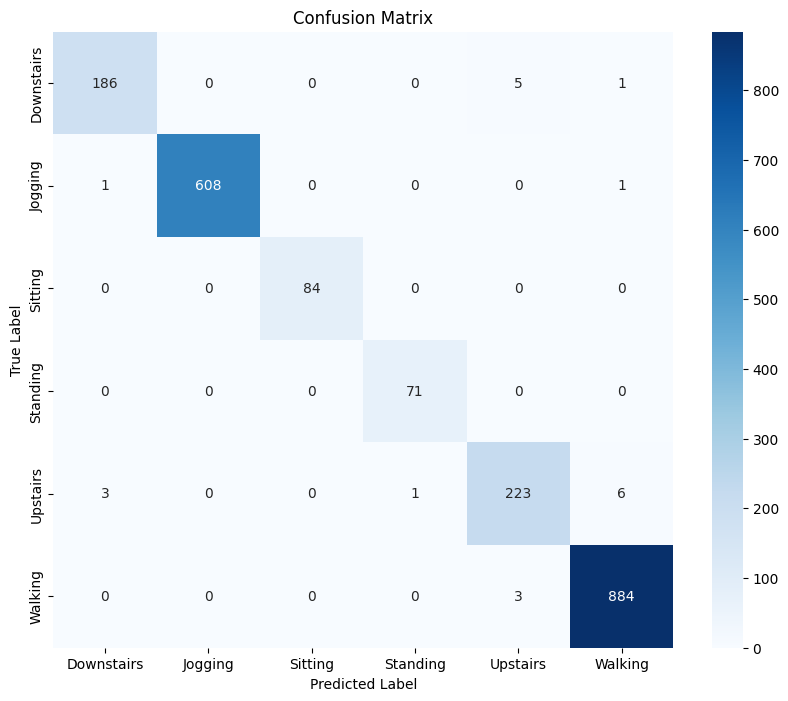

Weighted Precision: 0.9899
Weighted F1-Score: 0.9899


In [ ]:
# Data Preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import numpy as np

# Assuming X and y are already defined from the previous windowing step
X_raw = X

# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_raw = y_encoded

# Get class names in the correct order after encoding
class_names = label_encoder.classes_

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

# Get window_size and num_features from X_train shape
num_train_samples, window_size, num_features = X_train.shape
num_test_samples = X_test.shape[0]

# Reshape X_train and X_test for scaling: (num_samples * window_size, num_features)
X_train_reshaped = X_train.reshape(-1, num_features)
X_test_reshaped = X_test.reshape(-1, num_features)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

# Reshape back to (num_samples, window_size, num_features)
X_train = X_train_scaled.reshape(num_train_samples, window_size, num_features)
X_test = X_test_scaled.reshape(num_test_samples, window_size, num_features)

# Convert integer labels to one-hot encoding
num_classes = len(class_names)
y_train_hot = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_hot = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

# Determine input shape for the model from the prepared data
model_input_shape = (window_size, num_features)

# Build the model
wisdm_model = build_wisdm_model_hybrid(model_input_shape, num_classes)

# ==========================================
# PRINT LAYER-BY-LAYER ARCHITECTURE
# ==========================================
print("\n--- Model Architecture ---")
wisdm_model.summary()
print("--------------------------\n")

# Compile and Train
wisdm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
wisdm_model.fit(X_train, y_train_hot, epochs=20, batch_size=64, validation_split=0.1)

# Evaluate the model
loss, accuracy = wisdm_model.evaluate(X_test, y_test_hot, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions
y_pred_hot = wisdm_model.predict(X_test)
y_pred = np.argmax(y_pred_hot, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Calculate Precision, Recall (F1 is already in classification report)
precision = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")